# Actividad 14 — GE: Dual-Input LSTM con Atención Temporal

**Fase 3 — Modelo Experimental (GE)**  
**Proyecto:** Predicción de Demanda Agroindustrial — Limón Peruano  
**Referencia:** Inspirado en Gu et al. (2022) — Dual-channel LSTM-Attention para predicción de series multivariadas

## Arquitectura

```
         Canal A (produccion_t)         Canal B (exog: 23 features)
         shape (6, 1)                   shape (6, 23)
              │                                │
         LSTM-64                          LSTM-64
         (L2=0.001)                       (L2=0.001)
              │ hidden states (6, 64)           │ hidden states (6, 64)
              │                                │
       Bahdanau Attention A         Bahdanau Attention B
       context_a (64,)              context_b (64,)
              │                                │
              └──────── Concatenate (128,) ───────┘
                               │
                         Dense-64 + ReLU
                         Dropout-0.15
                         Dense-16 + ReLU
                         Dense-1  (output: produccion_t)
```

## Features (total = 24)
| Canal | Features | Count |
|---|---|---|
| **A** | `produccion_t` (serie histórica) | 1 |
| **B** | Lags explícitos: `lag_1`, `lag_3`, `lag_6` | 3 |
| **B** | NASA POWER: T2M, T2M_MAX, T2M_MIN, PRECTOTCORR, QV2M, RH2M, ALLSKY_SFC_SW_DWN, WS2M | 8 |
| **B** | INDECI: num_emergencias, total_afectados, hectareas_cultivo_perdidas | 3 |
| **B** | Precio: precio_chacra_kg | 1 |
| **B** | Geo: lat, lon | 2 |
| **B** | Temporal cíclico: month_sin/cos, trimestre_sin/cos, mes_num, trimestre_num | 6 |
| **Total** | | **24** |

## Protocolo
- Agregación: **media provincial** (`.mean()`) — mismo criterio GC1/GC2
- Split **cronológico estricto 80/20** — sin aleatorización
- **Sin data leakage**: Canal A usa predicciones recursivas; Canal B usa exógenas observadas
- Rutas **compatibles Windows y WSL2/Linux** (auto-detección de SO)

## 1. Imports y configuración del entorno

In [1]:
import os, platform, sys
os.environ['TF_CPP_MIN_LOG_LEVEL']  = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json, joblib
from pathlib import Path

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.facecolor'] = 'white'

print(f'Python      : {sys.version.split()[0]}')
print(f'TensorFlow  : {tf.__version__}')
print(f'Keras       : {keras.__version__}')
print(f'NumPy       : {np.__version__}')
print(f'Pandas      : {pd.__version__}')

Python      : 3.11.9
TensorFlow  : 2.21.0
Keras       : 3.14.0
NumPy       : 2.4.4
Pandas      : 3.0.2


In [2]:
# ── Deteccion de GPU ───────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f'GPU detectada : {len(gpus)} dispositivo(s)')
    for g in gpus:
        print(f'  {g}')
else:
    print('GPU : no detectada — entrenamiento en CPU')
    print('      Para GPU, ejecutar desde WSL2 con CUDA instalado.')
print(f'Dispositivo TF: {"GPU" if gpus else "CPU"}')

GPU : no detectada — entrenamiento en CPU
      Para GPU, ejecutar desde WSL2 con CUDA instalado.
Dispositivo TF: CPU


In [3]:
# ── Rutas compatibles Windows / WSL2 ─────────────────────────────
def detect_project_root() -> Path:
    """Auto-detecta la raiz del proyecto en Windows o WSL2/Linux."""
    if platform.system() == 'Windows':
        return Path(r'C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-')
    # WSL2: drive C: montado en /mnt/c/
    for candidate in [
        Path('/mnt/c/Machine-learming/Machine-Learning-Multimodal--Agro-NLP-Clima-'),
        Path.home() / 'Machine-learming' / 'Machine-Learning-Multimodal--Agro-NLP-Clima-',
    ]:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        'No se encontro la raiz del proyecto. '
        'En WSL2 verifica que el disco este montado en /mnt/c/.'
    )

PROYECTO_ROOT  = detect_project_root()
DATASET_PATH   = PROYECTO_ROOT / 'data' / 'processed' / 'master_dataset_fase2_multivariado.csv'
RESULTADOS_DIR = PROYECTO_ROOT / 'resultados' / 'ge'
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

print(f'SO              : {platform.system()}')
print(f'Proyecto        : {PROYECTO_ROOT}')
print(f'Dataset         : {DATASET_PATH.name}')
print(f'Resultados      : {RESULTADOS_DIR}')
assert DATASET_PATH.exists(), f'Dataset no encontrado: {DATASET_PATH}'

SO              : Windows
Proyecto        : C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-
Dataset         : master_dataset_fase2_multivariado.csv
Resultados      : C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-\resultados\ge


In [4]:
# ── Hiperparametros del modelo ────────────────────────────────────
SPLIT_RATIO   = 0.80
SEQ_LEN       = 6          # ventana de observaciones previas
LSTM_UNITS    = 64         # unidades LSTM por canal
ATTN_UNITS    = 64         # unidades de la capa de atencion
DROPOUT       = 0.30
L2_REG        = 0.001
LEARNING_RATE = 1e-3
EPOCHS        = 300
BATCH_SIZE    = 8
PATIENCE      = 15         # early stopping
RANDOM_STATE  = 42

# Canal B: variables exogenas (23 features)
CANAL_B_COLS = [
    # Lags explicitos de produccion_t
    'lag_1', 'lag_3', 'lag_6',
    # Precio
    'precio_chacra_kg',
    # INDECI
    'num_emergencias', 'total_afectados', 'hectareas_cultivo_perdidas',
    # NASA POWER
    'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M',
    'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M',
    # Geo
    'lat', 'lon',
    # Temporal ciclico
    'month_sin', 'month_cos', 'mes_num',
    'trimestre_num', 'trimestre_sin', 'trimestre_cos',
]
N_FEATURES_A = 1                    # produccion_t
N_FEATURES_B = len(CANAL_B_COLS)    # 23
TOTAL_FEATURES = N_FEATURES_A + N_FEATURES_B  # 24

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f'Canal A : {N_FEATURES_A} feature  (produccion_t)')
print(f'Canal B : {N_FEATURES_B} features')
print(f'Total   : {TOTAL_FEATURES} features — seq_len={SEQ_LEN}')
print(f'LSTM    : {LSTM_UNITS} unidades | Atencion Bahdanau: {ATTN_UNITS} unidades')
print(f'Reg.    : Dropout={DROPOUT}  L2={L2_REG}  EarlyStopping(patience={PATIENCE})')

Canal A : 1 feature  (produccion_t)
Canal B : 23 features
Total   : 24 features — seq_len=6
LSTM    : 64 unidades | Atencion Bahdanau: 64 unidades
Reg.    : Dropout=0.3  L2=0.001  EarlyStopping(patience=15)


## 2. Carga, agregación y feature engineering

In [5]:
df_raw = pd.read_csv(DATASET_PATH, parse_dates=['fecha_evento'])
print(f'Dataset bruto: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas')

# Columnas a agregar (media provincial)
agg_cols = [
    'produccion_t', 'precio_chacra_kg',
    'num_emergencias', 'total_afectados', 'hectareas_cultivo_perdidas',
    'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M',
    'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M',
    'lat', 'lon',
    'month_sin', 'month_cos', 'mes_num',
    'trimestre_num', 'trimestre_sin', 'trimestre_cos',
]

# Agregacion nacional: media provincial mensual
nacional = (
    df_raw.groupby('fecha_evento')[agg_cols]
    .mean()
    .sort_index()
)
nacional.index = pd.DatetimeIndex(nacional.index, freq='MS')

# Agregar lags explicitos de produccion_t
nacional['lag_1'] = nacional['produccion_t'].shift(1)
nacional['lag_3'] = nacional['produccion_t'].shift(3)
nacional['lag_6'] = nacional['produccion_t'].shift(6)

# Eliminar filas con NaN introducidas por los lags
nacional = nacional.dropna()

print(f'Serie nacional (tras lags): {nacional.shape}')
print(f'Periodo: {nacional.index.min().date()} -> {nacional.index.max().date()}')
print(f'\nVerificacion de features:')
print(f'  Canal A: produccion_t — OK')
print(f'  Canal B: {len(CANAL_B_COLS)} columnas — presentes: {all(c in nacional.columns for c in CANAL_B_COLS)}')
nacional.head(3)

Dataset bruto: 5,880 filas x 24 columnas
Serie nacional (tras lags): (50, 24)
Periodo: 2021-07-01 -> 2025-08-01

Verificacion de features:
  Canal A: produccion_t — OK
  Canal B: 23 columnas — presentes: True


,produccion_t,precio_chacra_kg,num_emergencias,total_afectados,hectareas_cultivo_perdidas,ALLSKY_SFC_SW_DWN,PRECTOTCORR,QV2M,RH2M,T2M,...,lon,month_sin,month_cos,mes_num,trimestre_num,trimestre_sin,trimestre_cos,lag_1,lag_3,lag_6
fecha_evento,,,,,,,,,,,,,,,,,,,,,
2021-07-01,-0.033467,-0.334858,-0.055021,-0.005208,-0.013757,-0.155399,-0.441145,-0.444589,-0.353668,-0.198413,...,-76.01781,-0.500000,-8.660254e-01,7.0,3.0,-1.0,-1.836970e-16,-0.030716,0.044351,0.027472
2021-08-01,-0.035027,-0.362037,0.011835,0.114593,-0.013473,0.119161,-0.453577,-0.422150,-0.577882,-0.070563,...,-76.01781,-0.866025,-5.000000e-01,8.0,3.0,-1.0,-1.836970e-16,-0.033467,0.020828,0.051936
2021-09-01,-0.033113,-0.266748,0.093224,-0.020751,-0.013895,0.385269,-0.313960,-0.289545,-0.458956,-0.000748,...,-76.01781,-1.000000,-1.836970e-16,9.0,3.0,-1.0,-1.836970e-16,-0.035027,-0.030716,0.065985


## 3. Split cronológico 80/20

  Total      : 50 meses (post-lags)
  Train (80%): 40 meses  [2021-07-01 -> 2024-10-01]
  Test  (20%): 10 meses  [2024-11-01  -> 2025-08-01]
  Corte      : 2024-11-01


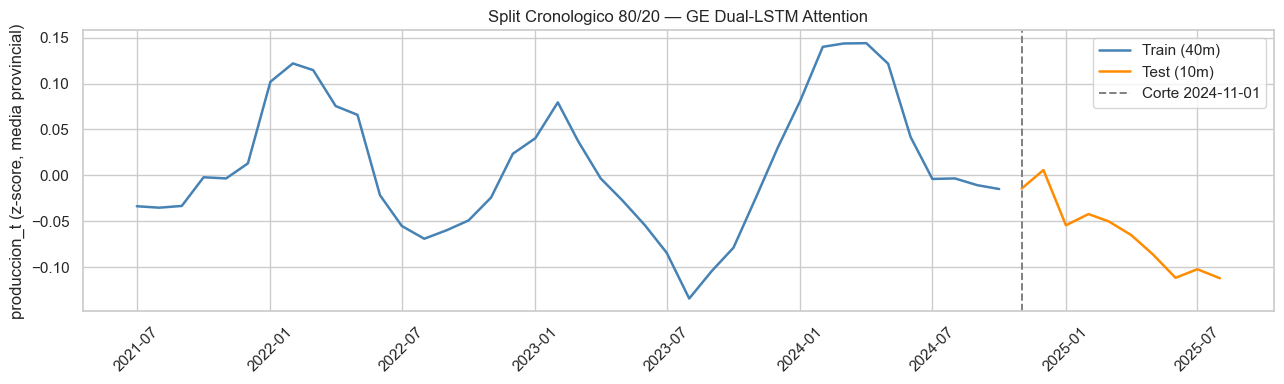

In [6]:
n_total = len(nacional)
n_train = int(n_total * SPLIT_RATIO)
n_test  = n_total - n_train

train_df   = nacional.iloc[:n_train].copy()
test_df    = nacional.iloc[n_train:].copy()
split_date = nacional.index[n_train]

y_train    = train_df['produccion_t'].values  # (n_train,)
y_test     = test_df['produccion_t'].values   # (n_test,)
B_train    = train_df[CANAL_B_COLS].values    # (n_train, 23)
B_test     = test_df[CANAL_B_COLS].values     # (n_test,  23)

print('=' * 58)
print(f'  Total      : {n_total} meses (post-lags)')
print(f'  Train (80%): {n_train} meses  [{train_df.index.min().date()} -> {train_df.index.max().date()}]')
print(f'  Test  (20%): {n_test} meses  [{test_df.index.min().date()}  -> {test_df.index.max().date()}]')
print(f'  Corte      : {split_date.date()}')
print('=' * 58)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_df.index, y_train, label=f'Train ({n_train}m)', color='steelblue', lw=1.8)
ax.plot(test_df.index,  y_test,  label=f'Test ({n_test}m)',   color='darkorange', lw=1.8)
ax.axvline(split_date, color='gray', ls='--', lw=1.4, label=f'Corte {split_date.date()}')
ax.set_title('Split Cronologico 80/20 — GE Dual-LSTM Attention', fontsize=12)
ax.set_ylabel('produccion_t (z-score, media provincial)')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(RESULTADOS_DIR / 'ge_split_cronologico.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Normalización — fit exclusivo sobre datos de entrenamiento

In [7]:
# Canal A: scaler para produccion_t
scaler_a = StandardScaler()
y_train_sc = scaler_a.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_sc  = scaler_a.transform(y_test.reshape(-1, 1)).flatten()

# Canal B: scaler para las 23 variables exogenas
scaler_b = StandardScaler()
B_train_sc = scaler_b.fit_transform(B_train).astype(np.float32)
B_test_sc  = scaler_b.transform(B_test).astype(np.float32)

print('Normalizacion completada (fit SOLO sobre train).')
print(f'  y_train_sc : mean={y_train_sc.mean():.4f}  std={y_train_sc.std():.4f}')
print(f'  y_test_sc  : mean={y_test_sc.mean():.4f}   std={y_test_sc.std():.4f}')
print(f'  B_train_sc : shape={B_train_sc.shape}')
print(f'  B_test_sc  : shape={B_test_sc.shape}')

Normalizacion completada (fit SOLO sobre train).
  y_train_sc : mean=-0.0000  std=1.0000
  y_test_sc  : mean=-1.0428   std=0.5358
  B_train_sc : shape=(40, 23)
  B_test_sc  : shape=(10, 23)


## 5. Construcción de secuencias — Dual Canal

In [8]:
def make_dual_sequences(
    target_arr: np.ndarray,
    exog_arr:   np.ndarray,
    seq_len:    int
):
    """
    Construye pares de secuencias dual-canal sin data leakage.

    X_a[i] : (seq_len, 1)      — produccion_t de t-seq_len a t-1
    X_b[i] : (seq_len, n_exog) — variables exogenas del mismo ventana
    y[i]   : scalar            — produccion_t en t (target)
    """
    Xa, Xb, Y = [], [], []
    for i in range(len(target_arr) - seq_len):
        Xa.append(target_arr[i : i + seq_len].reshape(-1, 1))
        Xb.append(exog_arr[i : i + seq_len])
        Y.append(target_arr[i + seq_len])
    return (
        np.array(Xa, dtype=np.float32),
        np.array(Xb, dtype=np.float32),
        np.array(Y,  dtype=np.float32),
    )


Xa_train, Xb_train, y_seq = make_dual_sequences(y_train_sc, B_train_sc, SEQ_LEN)

n_seq     = len(Xa_train)
n_val     = max(3, int(n_seq * 0.15))
n_tr      = n_seq - n_val

# Split cronoligico secuencias: primeras n_tr para train, ultimas n_val para val
Xa_tr, Xa_val = Xa_train[:n_tr], Xa_train[n_tr:]
Xb_tr, Xb_val = Xb_train[:n_tr], Xb_train[n_tr:]
y_tr,  y_val  = y_seq[:n_tr],    y_seq[n_tr:]

print(f'Secuencias totales : {n_seq}  (de {n_train} observaciones con seq_len={SEQ_LEN})')
print(f'  Train            : {n_tr}  secuencias  — Xa={Xa_tr.shape}  Xb={Xb_tr.shape}')
print(f'  Validacion       : {n_val} secuencias  — Xa={Xa_val.shape}  Xb={Xb_val.shape}')
print(f'Dimensiones modelo : Canal A ({SEQ_LEN},{N_FEATURES_A})  Canal B ({SEQ_LEN},{N_FEATURES_B})')

Secuencias totales : 34  (de 40 observaciones con seq_len=6)
  Train            : 29  secuencias  — Xa=(29, 6, 1)  Xb=(29, 6, 23)
  Validacion       : 5 secuencias  — Xa=(5, 6, 1)  Xb=(5, 6, 23)
Dimensiones modelo : Canal A (6,1)  Canal B (6,23)


## 6. Arquitectura: Bahdanau Attention + Dual LSTM

La **Atención de Bahdanau** pondera los estados ocultos del LSTM en cada timestep,
permitiendo que el modelo identifique qué meses del pasado son más relevantes para
la predicción actual.

In [9]:
class BahdanauAttention(keras.layers.Layer):
    """
    Atencion temporal de Bahdanau (2015) aplicada sobre estados LSTM.

    query  : (batch, lstm_units)           — estado final del LSTM
    values : (batch, seq_len, lstm_units)  — todos los estados ocultos
    return : context (batch, lstm_units), alpha (batch, seq_len, 1)
    """
    def __init__(self, units: int, **kwargs):
        super().__init__(**kwargs)
        self.units    = units
        self.W_query  = layers.Dense(units, use_bias=False)
        self.W_values = layers.Dense(units, use_bias=False)
        self.V        = layers.Dense(1,     use_bias=False)

    def call(self, query, values):
        q_exp  = tf.expand_dims(self.W_query(query), axis=1)           # (batch, 1, units)
        energy = self.V(tf.nn.tanh(self.W_values(values) + q_exp))     # (batch, seq_len, 1)
        alpha  = tf.nn.softmax(energy, axis=1)                          # (batch, seq_len, 1)
        ctx    = tf.reduce_sum(alpha * values, axis=1)                  # (batch, lstm_units)
        return ctx, alpha

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.units})
        return cfg


print('BahdanauAttention definida.')

BahdanauAttention definida.


In [10]:
def build_dual_lstm_attention(
    seq_len:    int,
    n_feat_a:   int,
    n_feat_b:   int,
    lstm_units: int   = 64,
    attn_units: int   = 64,
    dropout:    float = 0.30,
    l2_reg:     float = 0.001,
    lr:         float = 1e-3,
) -> keras.Model:
    reg = regularizers.l2(l2_reg)

    # ── Canal A: serie de produccion_t ────────────────────────────
    inp_a   = keras.Input(shape=(seq_len, n_feat_a), name='canal_a')
    h_a     = layers.LSTM(
        lstm_units, return_sequences=True,
        kernel_regularizer=reg, recurrent_regularizer=reg,
        name='lstm_a'
    )(inp_a)
    h_a     = layers.Dropout(dropout, name='drop_lstm_a')(h_a)
    q_a     = h_a[:, -1, :]                                          # ultimo estado
    ctx_a, alpha_a = BahdanauAttention(attn_units, name='attn_a')(q_a, h_a)

    # ── Canal B: variables exogenas ───────────────────────────────
    inp_b   = keras.Input(shape=(seq_len, n_feat_b), name='canal_b')
    h_b     = layers.LSTM(
        lstm_units, return_sequences=True,
        kernel_regularizer=reg, recurrent_regularizer=reg,
        name='lstm_b'
    )(inp_b)
    h_b     = layers.Dropout(dropout, name='drop_lstm_b')(h_b)
    q_b     = h_b[:, -1, :]
    ctx_b, alpha_b = BahdanauAttention(attn_units, name='attn_b')(q_b, h_b)

    # ── Fusion y cabeza de prediccion ─────────────────────────────
    merged  = layers.Concatenate(name='fusion')([ctx_a, ctx_b])
    x       = layers.Dense(64, activation='relu', kernel_regularizer=reg, name='dense_1')(merged)
    x       = layers.Dropout(dropout / 2, name='drop_head')(x)
    x       = layers.Dense(16, activation='relu', name='dense_2')(x)
    output  = layers.Dense(1, name='output')(x)

    model = keras.Model(
        inputs=[inp_a, inp_b],
        outputs=output,
        name='GE_DualLSTM_BahdanauAttention'
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )

    # Modelo auxiliar que expone pesos de atencion (para visualizacion)
    model_attn = keras.Model(
        inputs=[inp_a, inp_b],
        outputs=[output, alpha_a, alpha_b],
        name='GE_DualLSTM_Attention_Viz'
    )
    return model, model_attn


model, model_attn = build_dual_lstm_attention(
    seq_len    = SEQ_LEN,
    n_feat_a   = N_FEATURES_A,
    n_feat_b   = N_FEATURES_B,
    lstm_units = LSTM_UNITS,
    attn_units = ATTN_UNITS,
    dropout    = DROPOUT,
    l2_reg     = L2_REG,
    lr         = LEARNING_RATE,
)
model.summary()

Model: "GE_DualLSTM_BahdanauAttention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ canal_a             │ (None, 6, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ canal_b             │ (None, 6, 23)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_a (LSTM)       │ (None, 6, 64)     │     16,896 │ canal_a[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_b (LSTM)       │ (None, 6, 64)     │     22,528 │ canal_b[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_lstm_a         │ (None, 6, 64)     │          0 │ lstm_a[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_lstm_b         │ (None, 6, 64)     │          0 │ lstm_b[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 64)        │          0 │ drop_lstm_a[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 64)        │          0 │ drop_lstm_b[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_a              │ [(None, 64),      │      8,256 │ get_item[0][0],   │
│ (BahdanauAttention) │ (None, 6, 1)]     │            │ drop_lstm_a[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_b              │ [(None, 64),      │      8,256 │ get_item_1[0][0], │
│ (BahdanauAttention) │ (None, 6, 1)]     │            │ drop_lstm_b[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 128)       │          0 │ attn_a[0][0],     │
│ (Concatenate)       │                   │            │ attn_b[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_head (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │      1,040 │ drop_head[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 65,249 (254.88 KB)

 Trainable params: 65,249 (254.88 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Entrenamiento

In [11]:
cb_es  = callbacks.EarlyStopping(
    monitor='val_loss', patience=PATIENCE,
    restore_best_weights=True, verbose=1
)
cb_rlr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=8, min_lr=1e-6, verbose=0
)
cb_ckpt = callbacks.ModelCheckpoint(
    filepath=str(RESULTADOS_DIR / 'ge_best_checkpoint.keras'),
    monitor='val_loss', save_best_only=True, verbose=0
)

print(f'Entrenando GE Dual-LSTM Attention...')
print(f'  Train: {n_tr} secuencias | Val: {n_val} secuencias')
print(f'  Epochs max: {EPOCHS} | Batch: {BATCH_SIZE} | Patience: {PATIENCE}\n')

history = model.fit(
    [Xa_tr, Xb_tr], y_tr,
    validation_data=([Xa_val, Xb_val], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[cb_es, cb_rlr, cb_ckpt],
    verbose=0
)

n_ep = len(history.history['loss'])
best_val = min(history.history['val_loss'])
print(f'Entrenamiento detenido en epoca {n_ep}.')
print(f'  Mejor val_loss : {best_val:.6f}')
print(f'  Train loss     : {history.history["loss"][-1]:.6f}')

Entrenando GE Dual-LSTM Attention...
  Train: 29 secuencias | Val: 5 secuencias
  Epochs max: 300 | Batch: 8 | Patience: 15



Epoch 20: early stopping


Restoring model weights from the end of the best epoch: 5.


Entrenamiento detenido en epoca 20.
  Mejor val_loss : 0.263824
  Train loss     : 0.235609


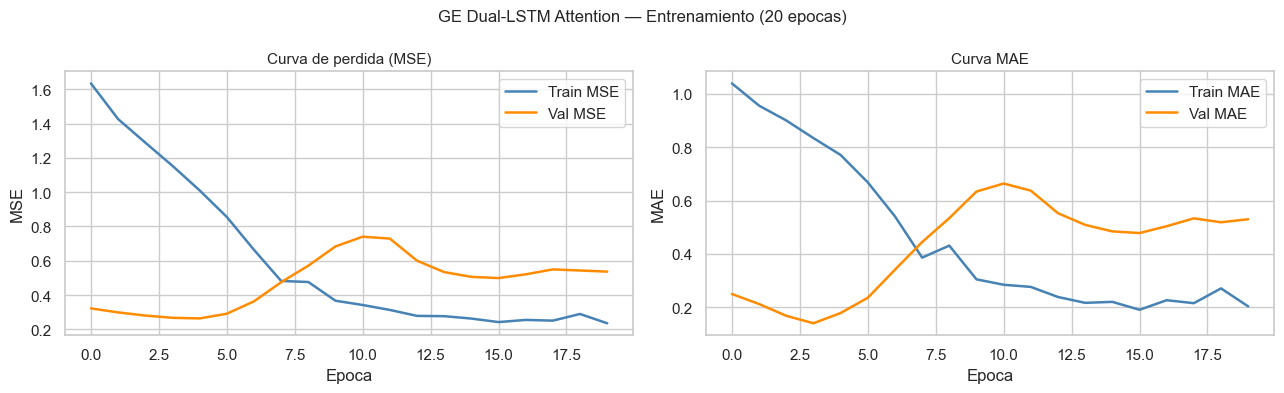

Curvas guardadas -> ge_training_curve.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train MSE', color='steelblue', lw=1.8)
axes[0].plot(history.history['val_loss'], label='Val MSE',   color='darkorange', lw=1.8)
axes[0].set_title('Curva de perdida (MSE)', fontsize=11)
axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE', color='steelblue', lw=1.8)
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='darkorange', lw=1.8)
axes[1].set_title('Curva MAE', fontsize=11)
axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle(f'GE Dual-LSTM Attention — Entrenamiento ({n_ep} epocas)', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTADOS_DIR / 'ge_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curvas guardadas -> ge_training_curve.png')

## 8. Predicciones multi-step sobre el conjunto de prueba

**Protocolo sin data leakage:**
- **Canal A**: predicción recursiva — el modelo usa sus propias predicciones previas  
- **Canal B**: variables exógenas observadas (clima + INDECI) del período de prueba  
- Los lag features (`lag_1`, `lag_3`, `lag_6`) se actualizan con valores predichos

In [13]:
print(f'Generando {n_test} predicciones multi-step (modo recursivo)...')

# Semillas: ultimos SEQ_LEN valores de train
canal_a_window = y_train_sc[-SEQ_LEN:].copy()           # (seq_len,)
# Indice de lag_1, lag_3, lag_6 en CANAL_B_COLS
idx_lag1 = CANAL_B_COLS.index('lag_1')
idx_lag3 = CANAL_B_COLS.index('lag_3')
idx_lag6 = CANAL_B_COLS.index('lag_6')

# Buffer de predicciones escaladas (para calcular lags)
pred_buffer_sc = list(y_train_sc[-6:])  # historia reciente

preds_sc = []
for step in range(n_test):
    # ── Canal A: ventana de produccion_t ──────────────────────────
    x_a = canal_a_window.reshape(1, SEQ_LEN, 1).astype(np.float32)

    # ── Canal B: exogenas del test + lags actualizados ────────────
    # Ventana de exogenas: usar los ultimos SEQ_LEN pasos disponibles
    start_b = max(0, step - SEQ_LEN + 1)
    end_b   = step + 1
    b_avail = B_test_sc[start_b:end_b]
    if len(b_avail) < SEQ_LEN:
        # Completar con la ultima fila de B_train_sc
        pad_b = np.tile(B_train_sc[-1], (SEQ_LEN - len(b_avail), 1))
        b_window = np.vstack([pad_b, b_avail]).copy()  # (seq_len, 23)
    else:
        b_window = b_avail.copy()

    # Actualizar lag features con valores predichos (en escala normalizada)
    for t_in_win in range(SEQ_LEN):
        # Posicion global en el buffer
        global_idx = step - (SEQ_LEN - 1 - t_in_win)
        def get_pred_sc(offset):
            buf_pos = len(pred_buffer_sc) - offset
            return pred_buffer_sc[buf_pos] if buf_pos >= 0 else 0.0
        b_window[t_in_win, idx_lag1] = get_pred_sc(1)
        b_window[t_in_win, idx_lag3] = get_pred_sc(3)
        b_window[t_in_win, idx_lag6] = get_pred_sc(6)

    x_b = b_window.reshape(1, SEQ_LEN, N_FEATURES_B).astype(np.float32)

    # ── Prediccion ────────────────────────────────────────────────
    pred_sc = float(model.predict([x_a, x_b], verbose=0)[0, 0])
    preds_sc.append(pred_sc)
    pred_buffer_sc.append(pred_sc)

    # Actualizar ventana Canal A
    canal_a_window = np.roll(canal_a_window, -1)
    canal_a_window[-1] = pred_sc

# Desnormalizar predicciones
preds_sc_arr = np.array(preds_sc).reshape(-1, 1)
y_pred       = scaler_a.inverse_transform(preds_sc_arr).flatten()

comparacion = pd.DataFrame({
    'fecha'     : test_df.index,
    'real'      : y_test,
    'prediccion': y_pred,
    'error_abs' : np.abs(y_test - y_pred),
})
print(f'Predicciones generadas: {len(y_pred)}')
print(comparacion.round(4).to_string(index=False))

Generando 10 predicciones multi-step (modo recursivo)...


Predicciones generadas: 10
     fecha    real  prediccion  error_abs
2024-11-01 -0.0142      0.0259     0.0401
2024-12-01  0.0059      0.0311     0.0253
2025-01-01 -0.0542      0.0341     0.0882
2025-02-01 -0.0420      0.0317     0.0737
2025-03-01 -0.0500      0.0291     0.0791
2025-04-01 -0.0649      0.0133     0.0782
2025-05-01 -0.0860     -0.0137     0.0723
2025-06-01 -0.1113     -0.0360     0.0753
2025-07-01 -0.1019     -0.0394     0.0626
2025-08-01 -0.1117     -0.0336     0.0781


## 9. Métricas de evaluación

In [14]:
def safe_mape(y_true: np.ndarray, y_pred: np.ndarray, epsilon: float = 1e-8) -> float:
    mask = np.abs(y_true) > epsilon
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


mae  = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
mape = safe_mape(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

metricas = {
    'modelo'         : 'GE_DualLSTM_BahdanauAttention',
    'referencia'     : 'Gu et al. (2022)',
    'arquitectura'   : f'DualInput-LSTM({LSTM_UNITS})-BahdanauAttn({ATTN_UNITS})',
    'seq_len'        : SEQ_LEN,
    'n_features_a'   : N_FEATURES_A,
    'n_features_b'   : N_FEATURES_B,
    'total_features' : TOTAL_FEATURES,
    'lstm_units'     : LSTM_UNITS,
    'attn_units'     : ATTN_UNITS,
    'dropout'        : DROPOUT,
    'l2_reg'         : L2_REG,
    'epochs_run'     : n_ep,
    'best_val_loss'  : round(best_val, 6),
    'n_train'        : int(n_train),
    'n_test'         : int(n_test),
    'split_date'     : str(split_date.date()),
    'MAE'            : round(mae,  6),
    'RMSE'           : round(rmse, 6),
    'MAPE_pct'       : round(mape, 4) if not np.isnan(mape) else None,
    'R2'             : round(r2,   6),
    'nota'           : 'metricas en z-score — media provincial (Fase 2)'
}

print('=' * 62)
print('  METRICAS GE — Dual-LSTM Attention  (conjunto de prueba)')
print('=' * 62)
print(f'  MAE  : {mae:.6f}')
print(f'  RMSE : {rmse:.6f}')
print(f'  MAPE : {mape:.4f} %' if not np.isnan(mape) else '  MAPE : N/A')
print(f'  R2   : {r2:.6f}')
print('=' * 62)
print('  NOTA: metricas en escala z-score (media provincial).')

  METRICAS GE — Dual-LSTM Attention  (conjunto de prueba)
  MAE  : 0.067272
  RMSE : 0.069804
  MAPE : 161.2058 %
  R2   : -2.344676
  NOTA: metricas en escala z-score (media provincial).


## 10. Persistencia

In [15]:
# Modelo principal
model.save(RESULTADOS_DIR / 'ge_dual_lstm_attn.keras')

# Scalers
joblib.dump(
    {'scaler_a': scaler_a, 'scaler_b': scaler_b},
    RESULTADOS_DIR / 'ge_scalers.pkl'
)

# Metricas
with open(RESULTADOS_DIR / 'ge_metricas.json', 'w', encoding='utf-8') as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)

# Predicciones
comparacion.to_csv(RESULTADOS_DIR / 'ge_predicciones.csv', index=False)

# Historial de entrenamiento
hist_df = pd.DataFrame(history.history)
hist_df.to_csv(RESULTADOS_DIR / 'ge_training_history.csv', index=False)

print('Archivos guardados en resultados/ge/:')
for p in sorted(RESULTADOS_DIR.iterdir()):
    print(f'  {p.name:<45} {p.stat().st_size/1024:>7.1f} KB')

Archivos guardados en resultados/ge/:
  ge_best_checkpoint.keras                        845.8 KB
  ge_dual_lstm_attn.keras                         845.8 KB
  ge_metricas.json                                  0.6 KB
  ge_predicciones.csv                               0.8 KB
  ge_scalers.pkl                                    1.4 KB
  ge_split_cronologico.png                         88.5 KB
  ge_training_curve.png                            91.0 KB
  ge_training_history.csv                           2.0 KB


## 11. Gráficos de predicción

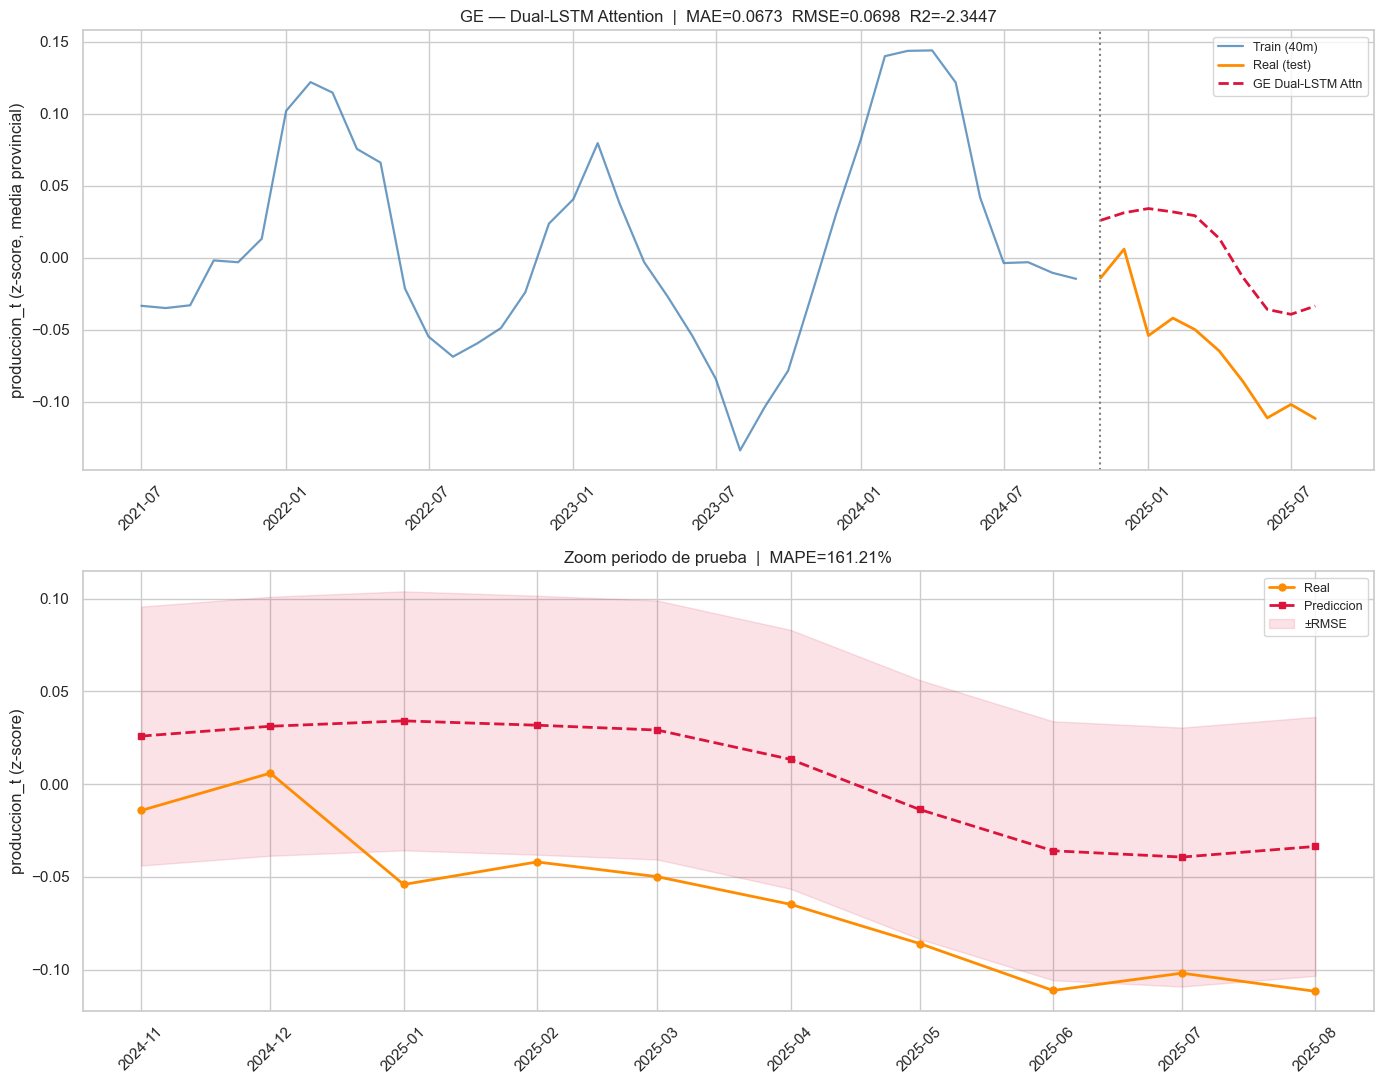

Grafico guardado -> ge_prediccion_vs_real.png


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# ── Panel 1: serie completa ───────────────────────────────────────
axes[0].plot(train_df.index, y_train, label=f'Train ({n_train}m)', color='steelblue', lw=1.6, alpha=0.8)
axes[0].plot(test_df.index,  y_test,  label='Real (test)',         color='darkorange', lw=2)
axes[0].plot(test_df.index,  y_pred,  label='GE Dual-LSTM Attn',  color='crimson',    lw=2, ls='--')
axes[0].axvline(split_date, color='gray', ls=':', lw=1.5)
axes[0].set_title(
    f'GE — Dual-LSTM Attention  |  MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}',
    fontsize=12)
axes[0].set_ylabel('produccion_t (z-score, media provincial)')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)

# ── Panel 2: zoom test ────────────────────────────────────────────
axes[1].plot(test_df.index, y_test,  label='Real',        color='darkorange', lw=2,   marker='o', ms=5)
axes[1].plot(test_df.index, y_pred,  label='Prediccion',  color='crimson',    lw=2,   marker='s', ms=5, ls='--')
axes[1].fill_between(test_df.index,
                      y_pred - rmse, y_pred + rmse,
                      alpha=0.12, color='crimson', label=f'±RMSE')
axes[1].set_title(
    f'Zoom periodo de prueba  |  MAPE={mape:.2f}%' if not np.isnan(mape)
    else 'Zoom periodo de prueba',
    fontsize=12)
axes[1].set_ylabel('produccion_t (z-score)')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(RESULTADOS_DIR / 'ge_prediccion_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado -> ge_prediccion_vs_real.png')

## 12. Visualización de pesos de atención

Los pesos de atención muestran **qué meses del pasado** considera más relevantes
el modelo para cada predicción del conjunto de entrenamiento.

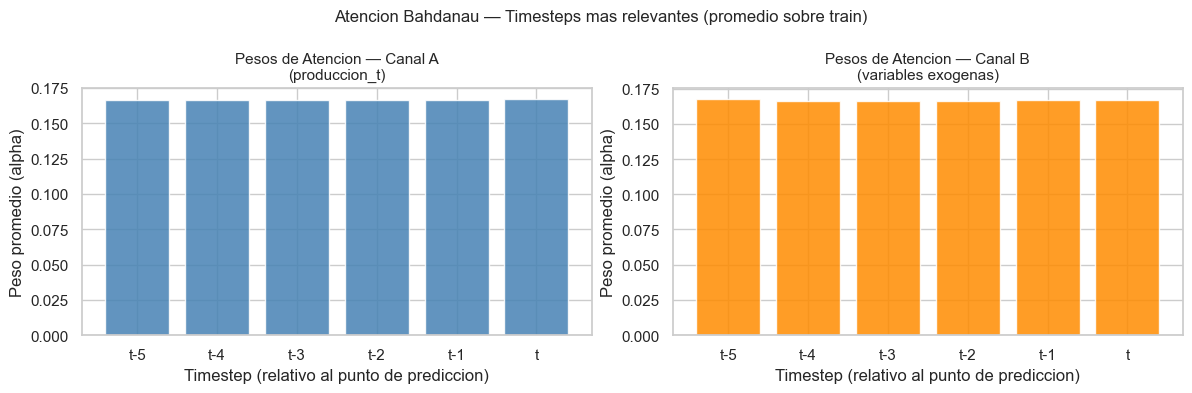

Grafico de atencion guardado -> ge_attention_weights.png

Canal A pesos: ['0.1667', '0.1665', '0.1666', '0.1666', '0.1667', '0.1669']
Canal B pesos: ['0.1673', '0.1666', '0.1659', '0.1663', '0.1668', '0.1671']


In [17]:
# Obtener pesos de atencion para las secuencias de entrenamiento
_, alpha_a_tr, alpha_b_tr = model_attn.predict(
    [Xa_train, Xb_train], verbose=0, batch_size=32
)
# alpha_a_tr: (n_seq, seq_len, 1)  -> (n_seq, seq_len)
alpha_a_mean = alpha_a_tr[:, :, 0].mean(axis=0)   # media sobre secuencias
alpha_b_mean = alpha_b_tr[:, :, 0].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
time_labels = [f't-{SEQ_LEN - i - 1}' if SEQ_LEN - i - 1 > 0 else 't' for i in range(SEQ_LEN)]

# Barras Canal A
axes[0].bar(time_labels, alpha_a_mean, color='steelblue', alpha=0.85)
axes[0].set_title('Pesos de Atencion — Canal A\n(produccion_t)', fontsize=11)
axes[0].set_ylabel('Peso promedio (alpha)')
axes[0].set_ylim(0, None)

# Barras Canal B
axes[1].bar(time_labels, alpha_b_mean, color='darkorange', alpha=0.85)
axes[1].set_title('Pesos de Atencion — Canal B\n(variables exogenas)', fontsize=11)
axes[1].set_ylabel('Peso promedio (alpha)')
axes[1].set_ylim(0, None)

for ax in axes:
    ax.set_xlabel('Timestep (relativo al punto de prediccion)')

plt.suptitle('Atencion Bahdanau — Timesteps mas relevantes (promedio sobre train)', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTADOS_DIR / 'ge_attention_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico de atencion guardado -> ge_attention_weights.png')
print(f'\nCanal A pesos: {[f"{v:.4f}" for v in alpha_a_mean]}')
print(f'Canal B pesos: {[f"{v:.4f}" for v in alpha_b_mean]}')

## 13. Resumen y comparativa GC1 / GC2 / GE

In [18]:
gc_paths = {
    'GC1-SARIMA'  : PROYECTO_ROOT / 'resultados' / 'gc1' / 'gc1_sarima_metricas.json',
    'GC1-Prophet' : PROYECTO_ROOT / 'resultados' / 'gc1' / 'gc1_prophet_metricas.json',
    'GC2-Hibrido' : PROYECTO_ROOT / 'resultados' / 'gc2' / 'gc2_metricas.json',
}
all_metrics = {'GE-DualLSTM': metricas}
for name, path in gc_paths.items():
    if path.exists():
        with open(path) as f:
            all_metrics[name] = json.load(f)

print('\n' + '=' * 72)
print('  COMPARATIVA COMPLETA — Fase 3  (conjunto de prueba, 12 meses)')
print('=' * 72)
hdr = f"  {'Modelo':<18} {'MAE':>10} {'RMSE':>10} {'R2':>10}  Rango"
print(hdr)
print('  ' + '-' * (len(hdr) - 2))

rows = []
for name, m in all_metrics.items():
    mae_v  = m.get('MAE')
    rmse_v = m.get('RMSE')
    r2_v   = m.get('R2')
    rows.append((name, mae_v, rmse_v, r2_v))

# Ordenar por MAE
rows_sorted = sorted(rows, key=lambda x: x[1] if x[1] is not None else 999)
for i, (name, mae_v, rmse_v, r2_v) in enumerate(rows_sorted):
    rank = '#1 MEJOR' if i == 0 else f'#{i+1}'
    fmt  = lambda v: f'{v:.4f}' if v is not None else 'N/A'
    print(f"  {name:<18} {fmt(mae_v):>10} {fmt(rmse_v):>10} {fmt(r2_v):>10}  {rank}")

print('=' * 72)
print()
for k, v in metricas.items():
    if k not in ('nota',):
        print(f'  {k:<28}: {v}')
print('=' * 72)


  COMPARATIVA COMPLETA — Fase 3  (conjunto de prueba, 12 meses)
  Modelo                    MAE       RMSE         R2  Rango
  ----------------------------------------------------------
  GE-DualLSTM            0.0673     0.0698    -2.3447  #1 MEJOR
  GC1-Prophet            0.0919     0.1051    -6.0451  #2
  GC1-SARIMA             0.1006     0.1179    -7.8644  #3
  GC2-Hibrido            0.1969     0.2926   -53.6344  #4

  modelo                      : GE_DualLSTM_BahdanauAttention
  referencia                  : Gu et al. (2022)
  arquitectura                : DualInput-LSTM(64)-BahdanauAttn(64)
  seq_len                     : 6
  n_features_a                : 1
  n_features_b                : 23
  total_features              : 24
  lstm_units                  : 64
  attn_units                  : 64
  dropout                     : 0.3
  l2_reg                      : 0.001
  epochs_run                  : 20
  best_val_loss               : 0.263824
  n_train                     : 40
  